# 📊 Students' Adaptability Level in Online Education

## Machine Learning Project – Phase 2  
### Exploratory Data Analysis & Data Preprocessing

## 🎯 Project Overview

Online education has become an essential part of modern learning environments.  
However, students adapt differently depending on various demographic, technological, and socio-economic factors.

This project aims to analyze students' adaptability levels in online education using machine learning techniques.

## ❓ Research Questions

1. Which demographic, technological, and socio-economic factors most significantly influence students' adaptability to online education?

2. What is the relative importance of each factor?

3. Which students are at higher risk of poor adaptability to online education based on their demographic and technological characteristics?

## 📂 Dataset Description

The dataset contains information about students and their adaptability levels in online education environments.

### Features Included

- Gender
- Age
- Education Level
- Institution Type
- IT Student
- Location
- Load Shedding
- Financial Condition
- Internet Type
- Network Type
- Class Duration
- Self LMS
- Device
- Adaptability Level (Target Variable)

## 🛠 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

## 📁 Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mdmahmudulhasansuzan/students-adaptability-level-in-online-education/students_adaptability_level_online_education.csv')

df.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,3-6,No,Tab,Moderate
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,1-3,Yes,Mobile,Moderate
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,1-3,No,Mobile,Moderate
3,Girl,11-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low


## 🔍 Dataset Overview

### Dataset Shape

In [3]:
df.shape

(1205, 14)

### Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               1205 non-null   object
 1   Age                  1205 non-null   object
 2   Education Level      1205 non-null   object
 3   Institution Type     1205 non-null   object
 4   IT Student           1205 non-null   object
 5   Location             1205 non-null   object
 6   Load-shedding        1205 non-null   object
 7   Financial Condition  1205 non-null   object
 8   Internet Type        1205 non-null   object
 9   Network Type         1205 non-null   object
 10  Class Duration       1205 non-null   object
 11  Self Lms             1205 non-null   object
 12  Device               1205 non-null   object
 13  Adaptivity Level     1205 non-null   object
dtypes: object(14)
memory usage: 131.9+ KB


### Statistical Summary

In [5]:
df.describe()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
count,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205,1205
unique,2,6,3,2,2,2,2,3,2,3,3,2,3,3
top,Boy,21-25,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,1-3,No,Mobile,Moderate
freq,663,374,530,823,901,935,1004,878,695,775,840,995,1013,625


## ⚠️ Checking Missing Values

In [6]:
df.isnull().sum()

Gender                 0
Age                    0
Education Level        0
Institution Type       0
IT Student             0
Location               0
Load-shedding          0
Financial Condition    0
Internet Type          0
Network Type           0
Class Duration         0
Self Lms               0
Device                 0
Adaptivity Level       0
dtype: int64

## 📊 Exploratory Data Analysis

### 🎯 Distribution of Adaptability Level
#### (Pie Chart)

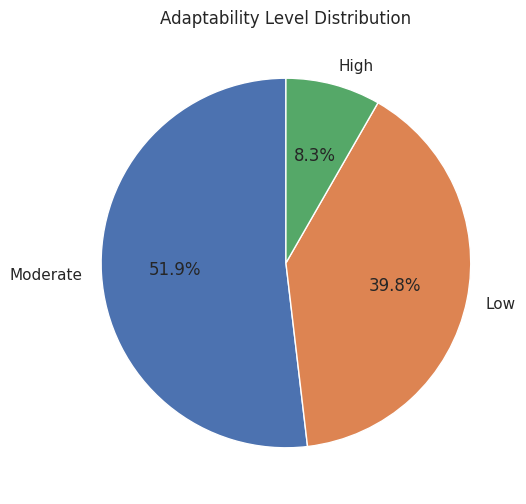

In [7]:
adapt_counts = df['Adaptivity Level'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(adapt_counts, labels=adapt_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Adaptability Level Distribution")
plt.show()

### 👩‍🎓 Gender vs Adaptability Level
#### (Stacked Bar Chart)

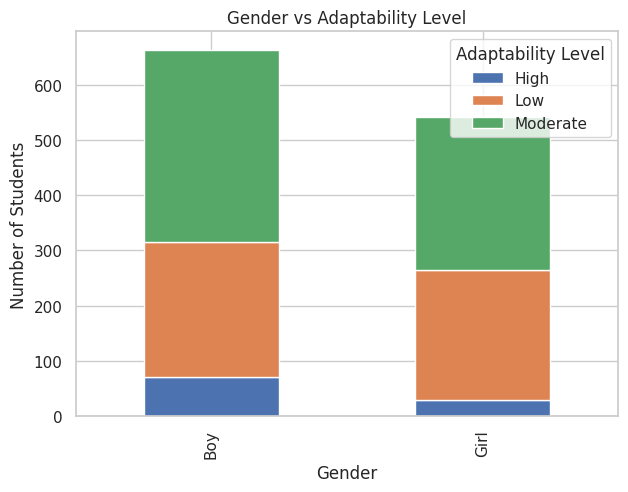

In [8]:
gender_adapt = pd.crosstab(df['Gender'], df['Adaptivity Level'])

gender_adapt.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title("Gender vs Adaptability Level")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.legend(title="Adaptability Level")
plt.show()

### 🎓 Education Level vs Adaptability Level
#### (Bar Chart)

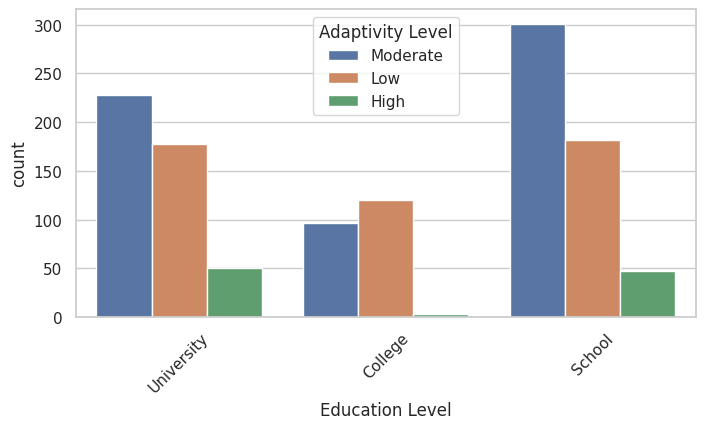

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x='Education Level', hue='Adaptivity Level', data=df)
plt.xticks(rotation=45)
plt.show()

### 📊 Financial Condition vs Adaptability Level 
#### (Grouped Bar Chart)

A grouped bar chart is used to compare adaptability levels among students with different financial conditions.

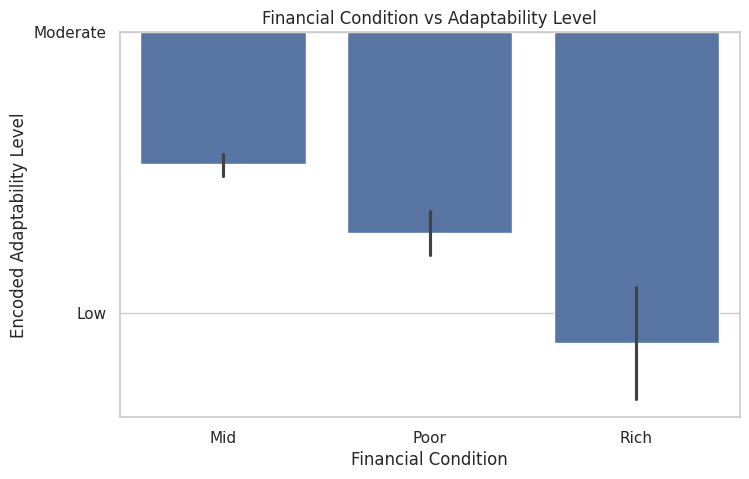

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(x='Financial Condition', y='Adaptivity Level', data=df)

plt.title("Financial Condition vs Adaptability Level")
plt.xlabel("Financial Condition")
plt.ylabel("Encoded Adaptability Level")
plt.show()

### 💻 Device Used vs Adaptability
#### (Bar Chart)

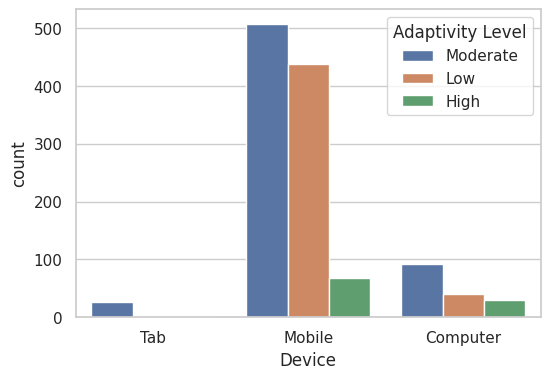

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Device', hue='Adaptivity Level', data=df)
plt.show()

### 📊 Location vs Adaptability Level 
#### (Mosaic Plot)

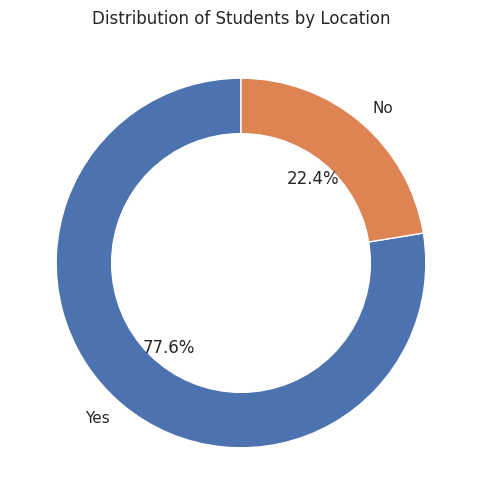

In [12]:
location_counts = df['Location'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(location_counts, labels=location_counts.index, autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Distribution of Students by Location")
plt.show()

### 🌐 Internet Type vs Adaptability
#### (Bar Chart)

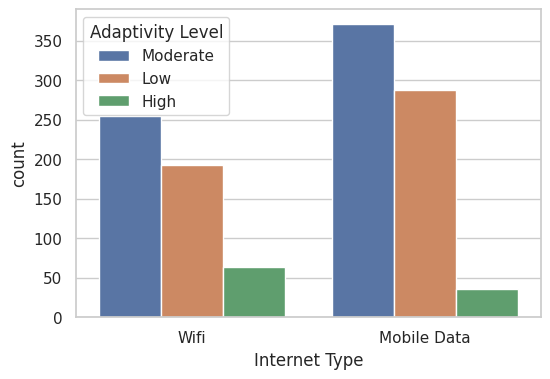

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Internet Type', hue='Adaptivity Level', data=df)
plt.show()

## ⚙️ Data Preprocessing

### 🔢 Encoding Categorical Variables

The dataset contains multiple categorical features such as Gender, Education Level, Device, Internet Type, and Financial Condition. Machine learning algorithms require numerical input, therefore these categorical variables must be converted into numerical form.

Label Encoding is used to transform each category into a numeric label while preserving the distinct categories of each feature.

In [14]:
le = LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

df.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,0,3,2,1,0,1,1,0,1,2,2,0,2,2
1,1,3,2,1,0,1,0,0,0,2,1,1,1,2
2,1,2,0,0,0,1,1,0,1,2,1,0,1,2
3,1,1,1,1,0,1,1,0,0,2,1,0,1,2
4,1,2,1,1,0,1,1,1,0,1,0,0,1,1


All categorical variables in the dataset were converted into numerical form using Label Encoding. This step is necessary because machine learning algorithms cannot process categorical text values directly.

Each category is assigned a unique numeric value, allowing the dataset to be used in model training in later phases.

## 🔥 Feature Correlation Analysis

After encoding the dataset, correlation analysis is performed to examine the relationships between features and the target variable.

Understanding correlations helps identify which factors may have stronger influence on students' adaptability to online education.

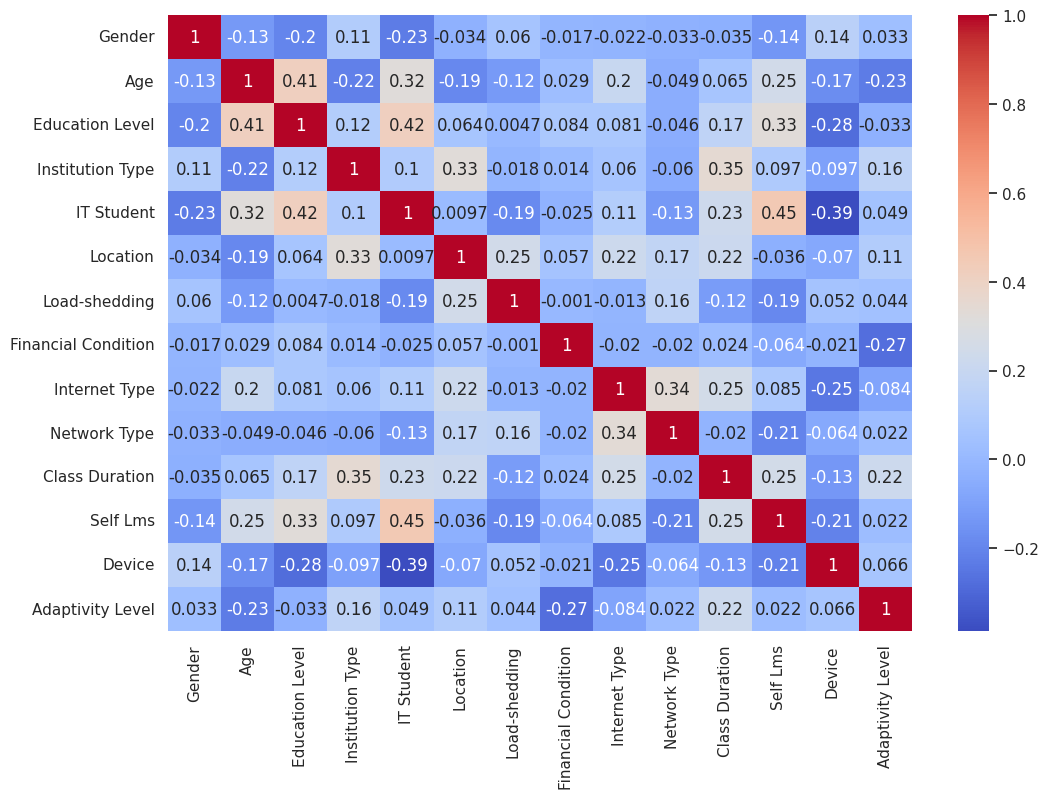

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

The heatmap visualizes the correlation between all features in the dataset. This helps in understanding which demographic, technological, or socio-economic factors are more closely associated with adaptability levels.

Such insights are useful for identifying important predictors that may influence model performance in later phases.

## ⚖️ Handling Class Imbalance using SMOTE

Class imbalance occurs when one category of the target variable has significantly more observations than others. This can cause machine learning models to become biased toward the majority class.

To address this issue, SMOTE (Synthetic Minority Over-sampling Technique) is applied to balance the dataset by generating synthetic samples for the minority classes.

In [16]:
from imblearn.over_sampling import SMOTE

X = df.drop('Adaptivity Level', axis=1)
y = df['Adaptivity Level']

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

SMOTE was applied to balance the distribution of the target variable. By generating synthetic samples for minority classes, the dataset becomes more balanced.

This helps machine learning models learn patterns from all classes equally and reduces the risk of biased predictions toward the majority class.

## 💾 Saving Preprocessed Dataset

To improve efficiency in later phases of the project, the preprocessed dataset is saved as a CSV file. This allows future notebooks to directly load the processed dataset without repeating the visualization and preprocessing steps.

In [17]:
df_resampled.to_csv("preprocessed_students_adaptability.csv", index=False)

## ✅ Conclusion

In this phase, exploratory data analysis and preprocessing were performed on the dataset.

Key steps included:
- Understanding dataset structure
- Visualizing feature distributions
- Encoding categorical variables
- Analyzing correlations
- Handling class imbalance using SMOTE

All features were retained in the dataset because each variable represents a potential demographic, technological, or socio-economic factor that may influence students' adaptability to online education. Removing these features at this stage could lead to loss of valuable information.

The processed dataset is saved and will be used in the next phase for training machine learning models.